In [2]:
# !pip install opencv-python
# !pip install matplotlib
# !pip install  scipy

import numpy as np
import cv2
from scipy import signal
import matplotlib.pyplot as plt
from PIL import Image


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


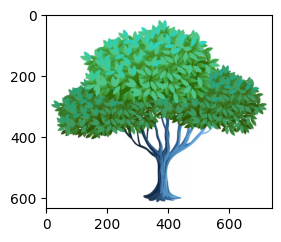

In [3]:
orig_img = cv2.imread('./tree_1308-36471.png')
plt.subplot(1,2,1)
plt.imshow(orig_img)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


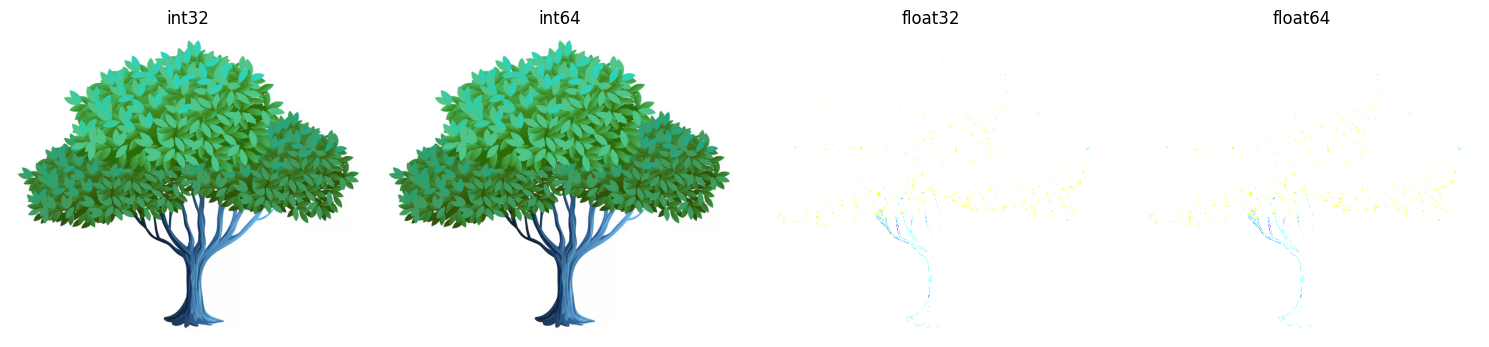

In [4]:
plt.figure(figsize=(15, 5))

img_int32 = orig_img.astype(np.int32)
plt.subplot(1, 4, 1)
plt.imshow(img_int32)
plt.title('int32')
plt.axis('off')

img_int64 = orig_img.astype(np.int64)
plt.subplot(1, 4, 2)
plt.imshow(img_int64)
plt.title('int64')
plt.axis('off')

img_float32 = orig_img.astype(np.float32)
plt.subplot(1, 4, 3)
plt.imshow(img_float32)
plt.title('float32')
plt.axis('off')

img_float64 = orig_img.astype(np.float64)
plt.subplot(1, 4, 4)
plt.imshow(img_float64)
plt.title('float64')
plt.axis('off')

plt.tight_layout()
plt.show()


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..510.0].


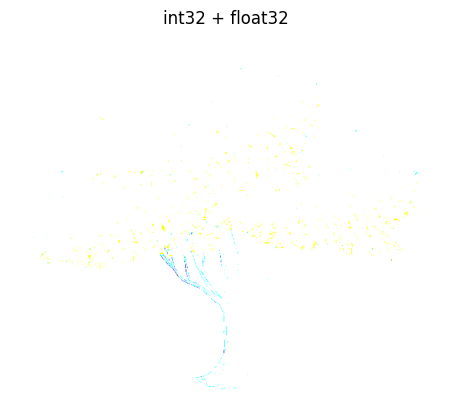

In [5]:
result_img = img_int32 + img_float32
plt.imshow(result_img)
plt.title('int32 + float32')
plt.axis('off')
plt.show()


Edge Detection Process:
Original image shape: (634, 740, 3)
Edge kernel:
[[ 0.  1.  0.]
 [ 1. -4.  1.]
 [ 0.  1.  0.]]

Step 1 - Processing Red channel (i=0)
  Channel shape: (634, 740)
  Channel value range: [0.00, 255.00]
Step 2 - Applying edge detection filter to Red channel
  mode='same': Output will have same size as input
  boundary='symm': Border pixels handled by mirroring values
Step 3 - Convolution complete for Red channel
  Result value range: [-478.00, 536.00]
Step 4 - Stored result in channel 0

Step 1 - Processing Green channel (i=1)
  Channel shape: (634, 740)
  Channel value range: [0.00, 255.00]
Step 2 - Applying edge detection filter to Green channel
  mode='same': Output will have same size as input
  boundary='symm': Border pixels handled by mirroring values
Step 3 - Convolution complete for Green channel
  Result value range: [-457.00, 560.00]
Step 4 - Stored result in channel 1

Step 1 - Processing Blue channel (i=2)
  Channel shape: (634, 740)
  Channel value ran

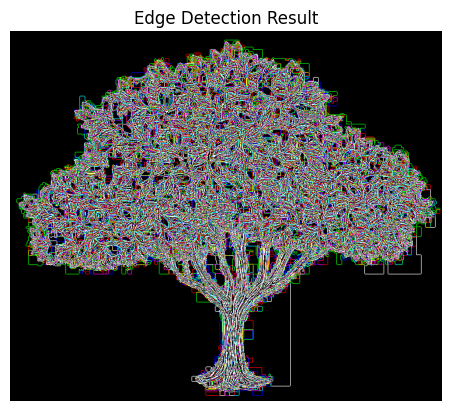

In [10]:
orig_img = orig_img.astype(np.float32)
edge_kernel = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]], dtype=np.float32)

print("Edge Detection Process:")
print(f"Original image shape: {orig_img.shape}")
print(f"Edge kernel:\n{edge_kernel}\n")

# Apply convolution to each channel separately
result_img = np.zeros_like(orig_img)

#The expression orig_img.shape[2] accesses the third dimension of the image array, which represents the number of color channels.

# Understanding the shape tuple: When you have orig_img.shape = (634, 740, 3), this is a tuple with three values. 
# The first value (634) is the height in pixels, the second value (740) is the width in pixels, and the third value (3) is the number of color channels. By using orig_img.shape[2], you're accessing that third element, which gives you 3.

# Why it equals 3: In a standard RGB color image, there are three channels: Red, Green, and Blue. 
# Each channel is a 2D array of the same dimensions (634×740 in this case), and when stacked together, they form a 3D array. So orig_img.shape[2] returns 3 because there are three color channels.



for i in range(orig_img.shape[2]):
    # 1. Extract one color channel
    channel = orig_img[:, :, i]
    channel_name = ['Red', 'Green', 'Blue'][i]
    print(f"Step 1 - Processing {channel_name} channel (i={i})")
    print(f"  Channel shape: {channel.shape}")
    print(f"  Channel value range: [{channel.min():.2f}, {channel.max():.2f}]")
    
    # 2. Apply the edge detection filter
    print(f"Step 2 - Applying edge detection filter to {channel_name} channel")
    print(f"  mode='same': Output will have same size as input")
    print(f"  boundary='symm': Border pixels handled by mirroring values")
    
    convolved = signal.convolve2d(channel, edge_kernel, mode='same', boundary='symm')
    
    print(f"Step 3 - Convolution complete for {channel_name} channel")
    print(f"  Result value range: [{convolved.min():.2f}, {convolved.max():.2f}]")
    
    # 5. Store the result
    result_img[:, :, i] = convolved
    print(f"Step 4 - Stored result in channel {i}\n")

# How this works:
# 1. Extract one color channel: orig_img[:, :, i] selects a single channel (Red=0, Green=1, or Blue=2)
#    from the RGB image, creating a 2D array of pixel values for that color.
#
# 2. Apply the edge detection filter: The edge_kernel (a 3×3 matrix) slides across the image,
#    multiplying neighboring pixels to detect edges where brightness changes rapidly.
#
# 3. Parameter 'mode=same': Keeps the output image the same size as the input by adding padding.
#
# 4. Parameter 'boundary=symm': Handles edge pixels by mirroring values at the borders,
#    which creates smoother results than using zeros.
#
# 5. Store the result: Each processed channel is saved back to result_img[:, :, i],
#    and the loop continues until all three color channels are filtered.

print("Edge detection complete!")
print(f"Final result shape: {result_img.shape}")
print(f"Final result value range: [{result_img.min():.2f}, {result_img.max():.2f}]")

plt.imshow(result_img.astype(np.uint8))
plt.title('Edge Detection Result')
plt.axis('off')
plt.show()


# Image Blurring 

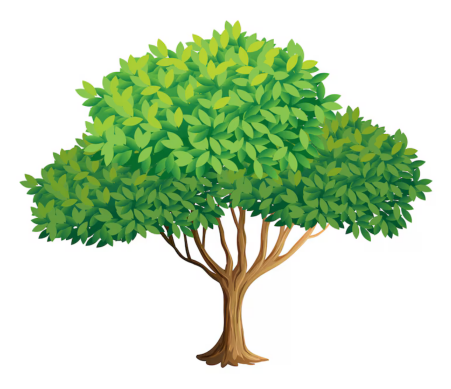

In [12]:
img = cv2.imread('./tree_1308-36471.png')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

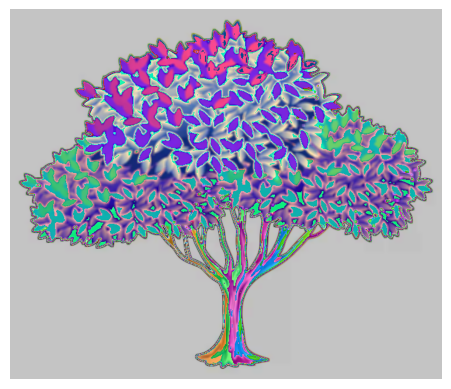

In [21]:
blur_kernel = np.ones((5, 5), dtype=np.float32) / 25

# Apply convolution to each channel separately
blurred_img = np.zeros_like(img, dtype=np.float32)

for i in range(img.shape[2]):
    channel = img[:, :, i]
    blurred_channel = signal.convolve2d(channel, blur_kernel, mode='same', boundary='symm')
    blurred_img[:, :, i] = blurred_channel

plt.imshow(cv2.cvtColor(blurred_img.astype(np.uint8), cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

Why Divide by 25?
The blur kernel np.ones((5, 5), dtype=np.float32) / 25 divides by 25 because that's the total number of pixels in the 5×5 kernel (5 × 5 = 25). This creates a proper averaging filter.

The Math Behind It
This creates:

Why Sum Must Equal 1
For proper blurring, the kernel sum should equal 1 to preserve brightness:

Result pixel = average of 25 neighboring pixels
Each neighbor contributes 1/25 (4%) to the final value
This maintains the original image brightness
What Happens with Other Numbers?
If you divide by a smaller number (e.g., /10):

❌ Too bright! Each pixel is multiplied by 2.5
Values exceed 255 → overflow → weird colors/artifacts (like in your image!)
The colorful noise happens because values wrap around or clip
If you divide by a larger number (e.g., /50):

❌ Too dark! Each pixel is multiplied by 0.5
Image becomes half as bright
The colorful artifacts in your image likely came from dividing by a number that's too small, causing pixel values to exceed the valid range (0-255), which creates overflow artifacts.

The Golden Rule for Blur Kernels
Always normalize so the sum equals 1:

This ensures:

✓ Proper averaging
✓ Brightness preserved
✓ No overflow artifacts
✓ Smooth, natural blur effect


# Color Inversion
Color inversion is a simple image processing technique that transforms each pixel's color to its complementary color.   

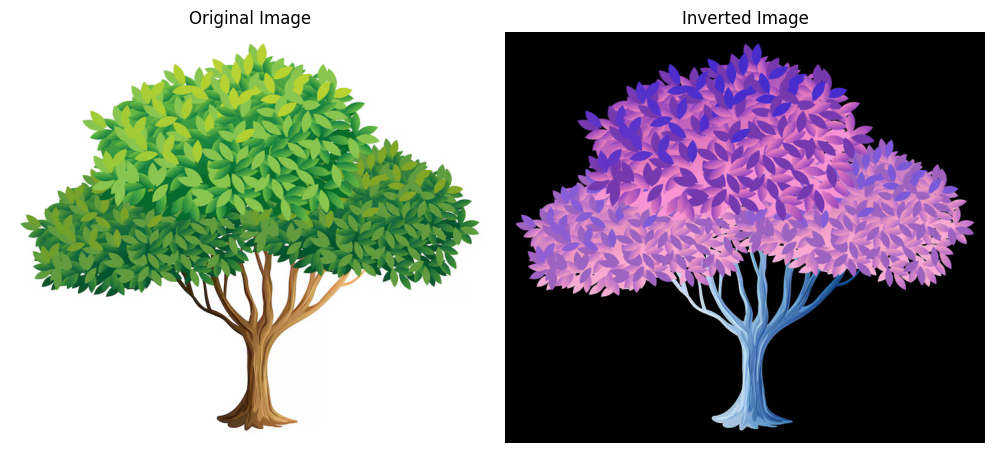

In [31]:
img = cv2.imread('./tree_1308-36471.png')
plt.figure(figsize=(15, 5))

# Original image
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

mtx1 = np.array(img)
mtx2 = np.zeros_like(mtx1)

# Inverted image
mtx2[:] = 255 - mtx1
plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(mtx2.astype(np.uint8), cv2.COLOR_BGR2RGB))
plt.title('Inverted Image')
plt.axis('off')

plt.tight_layout()
plt.show()


# Image Addtion / Image blending    

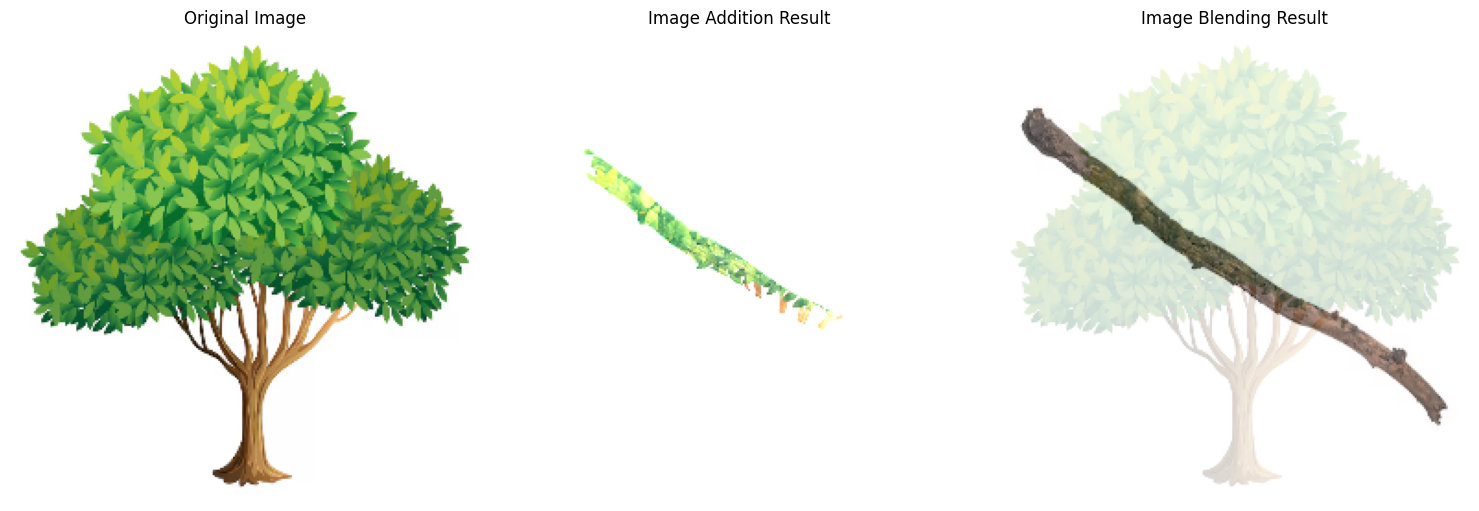

In [42]:
img = cv2.imread('./tree_1308-36471.png')
img = cv2.resize(img, (255, 255))
plt.figure(figsize=(15, 5)) 
# Original image
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

img2 = cv2.imread('./stick.png')
img2 = cv2.resize(img2, (255, 255))  # Resize to match img dimensions
img_result_add = cv2.add(img, img2)
plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(img_result_add, cv2.COLOR_BGR2RGB))
plt.title('Image Addition Result')
plt.axis('off') 

img_add_wt = cv2.addWeighted(img, 0.2, img2, 0.8, 0)
plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(img_add_wt, cv2.COLOR_BGR2RGB))
plt.title('Image Blending Result')
plt.axis('off')
plt.tight_layout()
plt.show()


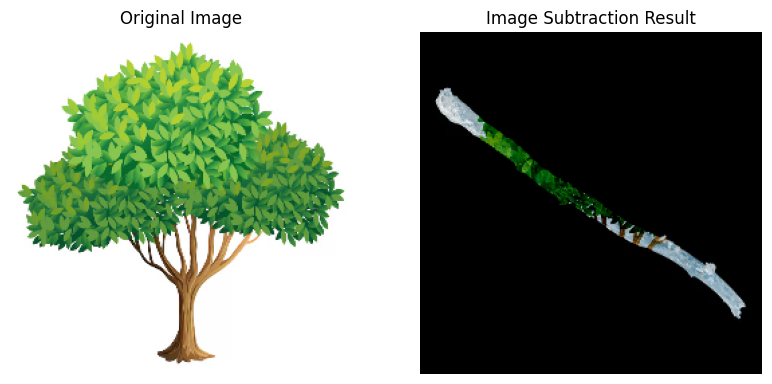

In [43]:
# image Subtraction
img = cv2.imread('./tree_1308-36471.png')
img = cv2.resize(img, (255, 255))
plt.figure(figsize=(15, 5))
# Original image
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')
img2 = cv2.imread('./stick.png')
img2 = cv2.resize(img2, (255, 255))  # Resize to
# match img dimensions
img_result_sub = cv2.subtract(img, img2)
plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(img_result_sub, cv2.COLOR_BGR2RGB))
plt.title('Image Subtraction Result')
plt.axis('off')
plt.show()

## Image Multiplication with Mask
Element-wise multiplication is commonly used for masking operations where you want to isolate or highlight specific regions of an image.

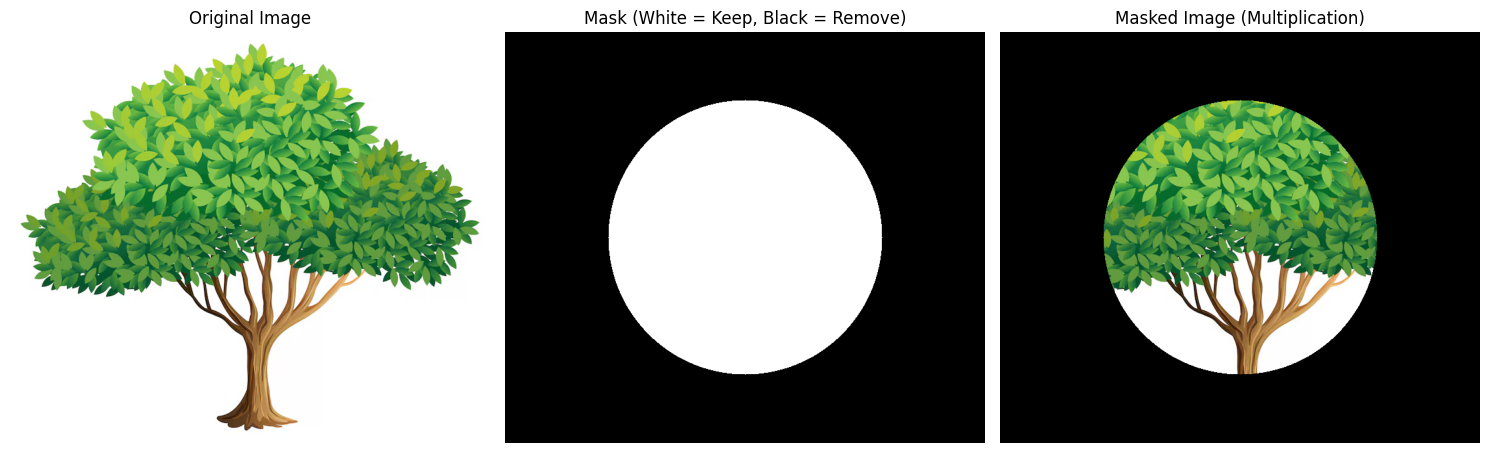

Original range: [0, 255]
Mask range: [0, 255]
Normalized mask range: [0.00, 1.00]
Result range: [0, 255]


In [45]:
# Load original image and mask
orig_img = cv2.imread('./tree_1308-36471.png')

# For masking, we'll create a simple circular mask
# Create a blank mask with the same dimensions as the image
h, w = orig_img.shape[:2]
mask = np.zeros((h, w, 3), dtype=np.uint8)

# Draw a white circle in the center (this will be the visible area)
center = (w // 2, h // 2)
radius = min(h, w) // 3
cv2.circle(mask, center, radius, (255, 255, 255), -1)

plt.figure(figsize=(15, 5))

# Show original image
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

# Show mask
plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(mask, cv2.COLOR_BGR2RGB))
plt.title('Mask (White = Keep, Black = Remove)')
plt.axis('off')

# Normalize mask to 0-1 range and multiply
mask_normalized = mask.astype(np.float32) / 255.0
masked_img = (orig_img.astype(np.float32) * mask_normalized).astype(np.uint8)

# Show result
plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(masked_img, cv2.COLOR_BGR2RGB))
plt.title('Masked Image (Multiplication)')
plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Original range: [{orig_img.min()}, {orig_img.max()}]")
print(f"Mask range: [{mask.min()}, {mask.max()}]")
print(f"Normalized mask range: [{mask_normalized.min():.2f}, {mask_normalized.max():.2f}]")
print(f"Result range: [{masked_img.min()}, {masked_img.max()}]")

### How Image Multiplication Works

**Key Concept:** Element-wise multiplication multiplies corresponding pixel values.

**Mask normalization (dividing by 255):**
- Converts mask values from [0, 255] to [0, 1.0]
- **Mask value = 1.0** (white) → keeps original pixel: `pixel × 1.0 = pixel`
- **Mask value = 0.0** (black) → removes pixel: `pixel × 0.0 = 0`
- **Mask value = 0.5** (gray) → half brightness: `pixel × 0.5 = pixel/2`

**Example calculation:**
```
Original pixel: RGB(200, 150, 100)
Mask value: 255 (white) → normalized to 1.0
Result: (200×1.0, 150×1.0, 100×1.0) = RGB(200, 150, 100) ✓ Original

Original pixel: RGB(200, 150, 100)
Mask value: 0 (black) → normalized to 0.0
Result: (200×0.0, 150×0.0, 100×0.0) = RGB(0, 0, 0) ✓ Black
```

This technique is widely used for:
- **Background removal** - mask out unwanted areas
- **Region of interest (ROI)** - focus on specific parts
- **Image compositing** - combine multiple images

# Image Division
Image division divides pixel values of one image by another. Commonly used for normalization, illumination correction, and creating special effects.

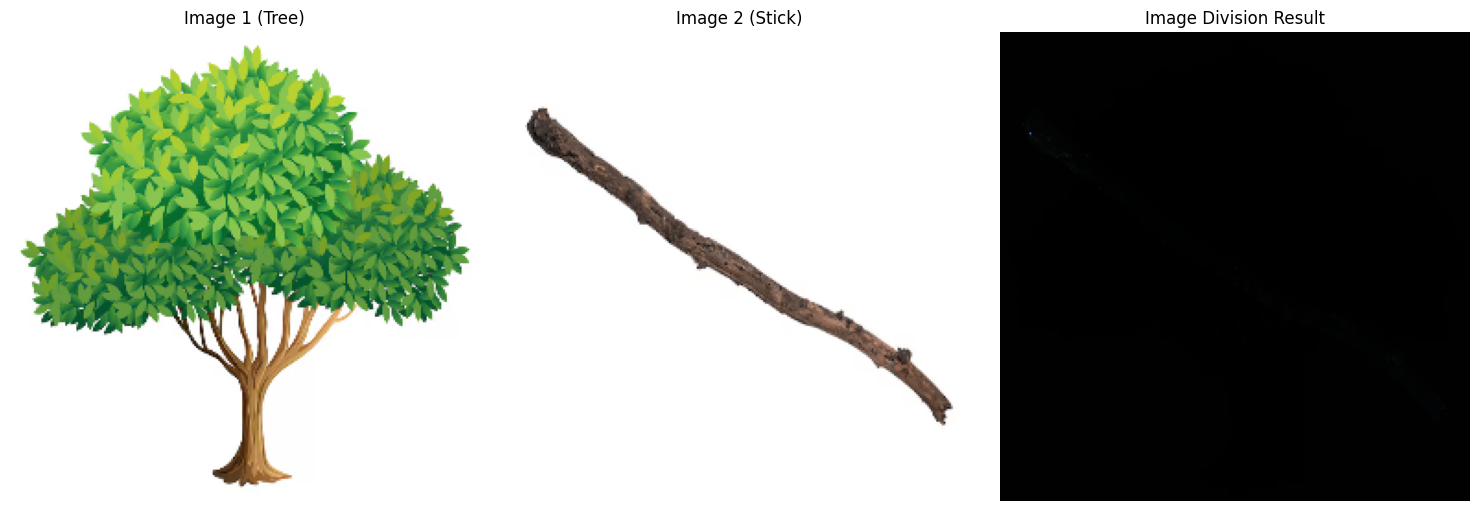

Image 1 range: [0, 255]
Image 2 range: [1, 255]
Division result range (normalized): [0, 255]


In [51]:
# Image Division Example
img = cv2.imread('./tree_1308-36471.png')
img = cv2.resize(img, (255, 255))
plt.figure(figsize=(15, 5))

# Original image
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Image 1 (Tree)')
plt.axis('off')

img2 = cv2.imread('./stick.png')
img2 = cv2.resize(img2, (255, 255))

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
plt.title('Image 2 (Stick)')
plt.axis('off')

# Division requires careful handling to avoid division by zero
# Add small constant to avoid division by zero
img2_safe = img2.astype(np.float64) + 1e-7
img_float = img.astype(np.float64)

# Divide and normalize back to 0-255 range
img_result_div = cv2.divide(img_float, img2_safe)

# Normalize to 0-255 for display
img_result_div = cv2.normalize(img_result_div, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(img_result_div, cv2.COLOR_BGR2RGB))
plt.title('Image Division Result')
plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Image 1 range: [{img.min()}, {img.max()}]")
print(f"Image 2 range: [{img2.min()}, {img2.max()}]")
print(f"Division result range (normalized): [{img_result_div.min()}, {img_result_div.max()}]")

### How Image Division Works

**Key Concepts:**
- Divides each pixel in Image 1 by the corresponding pixel in Image 2
- Formula: `Result[x,y] = Image1[x,y] / Image2[x,y]`

**Important Considerations:**

1. **Division by zero problem:**
   - If Image 2 has pixel value = 0, division causes infinity/error
   - Solution: Add small constant (e.g., `1e-7`) to denominator

2. **Result normalization:**
   - Division can produce values > 255 or < 0
   - Use `cv2.normalize()` to map results back to [0, 255] range

3. **Data type:**
   - Use `float32` to avoid integer overflow
   - Convert back to `uint8` for display

**Example calculation:**
```
Pixel1 = 200, Pixel2 = 100
Result = 200 / 100 = 2.0
After normalization: scaled to fit [0, 255]
```

**Common Applications:**
- **Illumination correction** - Remove lighting variations
- **Background normalization** - Flatten uneven backgrounds  
- **Contrast enhancement** - Adjust brightness ratios
- **Creating special effects** - Artistic manipulations